# Array API Benchmark: Real Performance Impact

This notebook compares runtime of SysIdentPy algorithms with and without Array API support enabled (`array_api_dispatch`). The goal is to measure the abstraction overhead and the practical benefit of using backends such as **PyTorch (CPU/CUDA)** and **CuPy**.

## Tested scenarios

| Scenario | Backend | `array_api_dispatch` |
|---------|---------|---------------------|
| **Baseline** | NumPy | `False` (default) |
| **NumPy + dispatch** | NumPy | `True` |
| **PyTorch CPU** | torch (CPU) | `True` |
| **PyTorch CUDA** | torch (CUDA) | `True` |
| **CuPy** | CuPy (CUDA) | `True` |


In [1]:
import time
import warnings
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

from sysidentpy import config_context
from sysidentpy.model_structure_selection import FROLS, AOLS
from sysidentpy.basis_function import Polynomial
from sysidentpy.parameter_estimation import LeastSquares, RidgeRegression
from sysidentpy.metrics import root_relative_squared_error
from sysidentpy.utils.generate_data import get_siso_data, get_miso_data

warnings.filterwarnings("ignore")

# Detect available backends
BACKENDS = {"NumPy": True}

try:
    import torch

    BACKENDS["PyTorch CPU"] = True
    if torch.cuda.is_available():
        BACKENDS["PyTorch CUDA"] = True
        print(f"Detected GPU: {torch.cuda.get_device_name(0)}")
except ImportError:
    torch = None

try:
    import cupy as cp

    BACKENDS["CuPy"] = True
except ImportError:
    cp = None

print(f"Available backends: {list(BACKENDS.keys())}")

Detected GPU: NVIDIA GeForce RTX 3080 Ti
Available backends: ['NumPy', 'PyTorch CPU', 'PyTorch CUDA', 'CuPy']


In [2]:
import sysidentpy

sysidentpy.__version__

'0.8.0'

## Helper functions

Utility helper functions used by the benchmark: convert NumPy arrays to backend arrays, synchronize GPU operations, and measure timings.


In [3]:
def to_backend(x_train, x_valid, y_train, y_valid, backend):
    """Convert NumPy arrays to the specified backend."""
    if backend == "NumPy":
        return x_train, x_valid, y_train, y_valid

    if backend == "PyTorch CPU":
        return (
            torch.tensor(x_train, dtype=torch.float64),
            torch.tensor(x_valid, dtype=torch.float64),
            torch.tensor(y_train, dtype=torch.float64),
            torch.tensor(y_valid, dtype=torch.float64),
        )

    if backend == "PyTorch CUDA":
        return (
            torch.tensor(x_train, dtype=torch.float64, device="cuda"),
            torch.tensor(x_valid, dtype=torch.float64, device="cuda"),
            torch.tensor(y_train, dtype=torch.float64, device="cuda"),
            torch.tensor(y_valid, dtype=torch.float64, device="cuda"),
        )

    if backend == "CuPy":
        return (
            cp.asarray(x_train),
            cp.asarray(x_valid),
            cp.asarray(y_train),
            cp.asarray(y_valid),
        )

    raise ValueError(f"Unknown backend: {backend}")


def sync_backend(backend):
    """Synchronize asynchronous GPU operations before measuring time."""
    if backend == "PyTorch CUDA":
        torch.cuda.synchronize()
    elif backend == "CuPy":
        cp.cuda.Stream.null.synchronize()


def benchmark_fit(
    model_cls, model_kwargs, x_train, y_train, backend, n_runs=5, dispatch=False
):
    """Measure the time to run `model.fit()`.

    If `dispatch=True` the call is wrapped in `config_context(array_api_dispatch=True)`.
    """
    times = []
    for _ in range(n_runs):
        model = model_cls(**model_kwargs)
        sync_backend(backend)
        t0 = time.perf_counter()

        if dispatch or backend != "NumPy":
            with config_context(array_api_dispatch=True):
                model.fit(X=x_train, y=y_train)
        else:
            model.fit(X=x_train, y=y_train)

        sync_backend(backend)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return np.median(times)


def benchmark_predict(model, x_valid, y_valid, backend, n_runs=5):
    """Measure the time to run `model.predict()` (dispatch=True)."""
    times = []
    for _ in range(n_runs):
        sync_backend(backend)
        t0 = time.perf_counter()

        with config_context(array_api_dispatch=True):
            yhat = model.predict(X=x_valid, y=y_valid)

        sync_backend(backend)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return np.median(times)

## 1. FROLS benchmark — Different dataset sizes

Compare `fit()` and `predict()` runtime for different dataset sizes and backends.

In [4]:
import gc


def free_gpu_memory():
    """Free GPU memory caches to avoid OOM between benchmark runs."""
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()
    if cp is not None:
        cp.get_default_memory_pool().free_all_blocks()


SIZES = [1_000, 5_000, 10_000, 25_000]
N_RUNS = 5

frols_kwargs = dict(
    ylag=10,
    xlag=10,
    order_selection=True,
    n_info_values=10,
    basis_function=Polynomial(degree=4),
    estimator=LeastSquares(),
)

fit_results = defaultdict(dict)  # {backend: {size: time}}
pred_results = defaultdict(dict)

for n in SIZES:
    print(f"\n--- n = {n:,} ---")
    x_train_np, x_valid_np, y_train_np, y_valid_np = get_siso_data(
        n=n, colored_noise=False, sigma=0.001, train_percentage=80
    )

    # --- Baseline: NumPy (no dispatch) ---
    t_fit = benchmark_fit(
        FROLS, frols_kwargs, x_train_np, y_train_np, "NumPy", n_runs=N_RUNS
    )
    model_baseline = FROLS(**frols_kwargs)
    model_baseline.fit(X=x_train_np, y=y_train_np)
    t_pred = benchmark_predict(
        model_baseline, x_valid_np, y_valid_np, "NumPy", n_runs=N_RUNS
    )
    fit_results["NumPy (no dispatch)"][n] = t_fit
    pred_results["NumPy (no dispatch)"][n] = t_pred
    print(f"  NumPy (no dispatch):  fit={t_fit:.4f}s  predict={t_pred:.4f}s")

    # --- NumPy WITH dispatch ---
    t_fit = benchmark_fit(
        FROLS,
        frols_kwargs,
        x_train_np,
        y_train_np,
        "NumPy",
        n_runs=N_RUNS,
        dispatch=True,
    )
    model_dispatch = FROLS(**frols_kwargs)
    with config_context(array_api_dispatch=True):
        model_dispatch.fit(X=x_train_np, y=y_train_np)
    t_pred = benchmark_predict(
        model_dispatch, x_valid_np, y_valid_np, "NumPy", n_runs=N_RUNS
    )
    fit_results["NumPy (with dispatch)"][n] = t_fit
    pred_results["NumPy (with dispatch)"][n] = t_pred
    print(f"  NumPy (with dispatch):  fit={t_fit:.4f}s  predict={t_pred:.4f}s")

    # --- PyTorch CPU ---
    if "PyTorch CPU" in BACKENDS:
        xt, xv, yt, yv = to_backend(
            x_train_np, x_valid_np, y_train_np, y_valid_np, "PyTorch CPU"
        )
        t_fit = benchmark_fit(
            FROLS,
            frols_kwargs,
            xt,
            yt,
            "PyTorch CPU",
            n_runs=N_RUNS,
        )
        model_torch = FROLS(**frols_kwargs)
        with config_context(array_api_dispatch=True):
            model_torch.fit(X=xt, y=yt)
        t_pred = benchmark_predict(model_torch, xv, yv, "PyTorch CPU", n_runs=N_RUNS)
        fit_results["PyTorch CPU"][n] = t_fit
        pred_results["PyTorch CPU"][n] = t_pred
        print(f"  PyTorch CPU:           fit={t_fit:.4f}s  predict={t_pred:.4f}s")

    # --- PyTorch CUDA ---
    if "PyTorch CUDA" in BACKENDS:
        free_gpu_memory()
        xt, xv, yt, yv = to_backend(
            x_train_np, x_valid_np, y_train_np, y_valid_np, "PyTorch CUDA"
        )
        # warmup
        warmup_model = FROLS(**frols_kwargs)
        with config_context(array_api_dispatch=True):
            warmup_model.fit(X=xt, y=yt)
        torch.cuda.synchronize()

        t_fit = benchmark_fit(
            FROLS,
            frols_kwargs,
            xt,
            yt,
            "PyTorch CUDA",
            n_runs=N_RUNS,
        )
        model_cuda = FROLS(**frols_kwargs)
        with config_context(array_api_dispatch=True):
            model_cuda.fit(X=xt, y=yt)
        t_pred = benchmark_predict(model_cuda, xv, yv, "PyTorch CUDA", n_runs=N_RUNS)
        fit_results["PyTorch CUDA"][n] = t_fit
        pred_results["PyTorch CUDA"][n] = t_pred
        print(f"  PyTorch CUDA:          fit={t_fit:.4f}s  predict={t_pred:.4f}s")
        del xt, xv, yt, yv, model_cuda
        free_gpu_memory()

    # --- CuPy ---
    if "CuPy" in BACKENDS:
        free_gpu_memory()
        xt, xv, yt, yv = to_backend(
            x_train_np, x_valid_np, y_train_np, y_valid_np, "CuPy"
        )
        t_fit = benchmark_fit(
            FROLS,
            frols_kwargs,
            xt,
            yt,
            "CuPy",
            n_runs=N_RUNS,
        )
        model_cupy = FROLS(**frols_kwargs)
        with config_context(array_api_dispatch=True):
            model_cupy.fit(X=xt, y=yt)
        t_pred = benchmark_predict(model_cupy, xv, yv, "CuPy", n_runs=N_RUNS)
        fit_results["CuPy"][n] = t_fit
        pred_results["CuPy"][n] = t_pred
        print(f"  CuPy:                  fit={t_fit:.4f}s  predict={t_pred:.4f}s")
        del xt, xv, yt, yv, model_cupy
        free_gpu_memory()


--- n = 1,000 ---
  NumPy (no dispatch):  fit=6.2549s  predict=0.0023s
  NumPy (with dispatch):  fit=6.1141s  predict=0.0022s
  PyTorch CPU:           fit=4.3155s  predict=0.0035s
  PyTorch CUDA:          fit=1.7306s  predict=0.0030s
  CuPy:                  fit=2.0745s  predict=0.0024s

--- n = 5,000 ---
  NumPy (no dispatch):  fit=32.5525s  predict=0.0111s
  NumPy (with dispatch):  fit=31.3170s  predict=0.0117s
  PyTorch CPU:           fit=20.9707s  predict=0.0128s
  PyTorch CUDA:          fit=2.0746s  predict=0.0114s
  CuPy:                  fit=2.3780s  predict=0.0115s

--- n = 10,000 ---
  NumPy (no dispatch):  fit=63.0144s  predict=0.0224s
  NumPy (with dispatch):  fit=63.0671s  predict=0.0225s
  PyTorch CPU:           fit=41.0679s  predict=0.0271s
  PyTorch CUDA:          fit=2.5184s  predict=0.0224s
  CuPy:                  fit=2.8966s  predict=0.0251s

--- n = 25,000 ---
  NumPy (no dispatch):  fit=166.3386s  predict=0.0584s
  NumPy (with dispatch):  fit=166.0494s  predict=0.

## 2. Results visualization — FROLS `fit()`

Plot `fit()` and `predict()` times for each backend and dataset size.

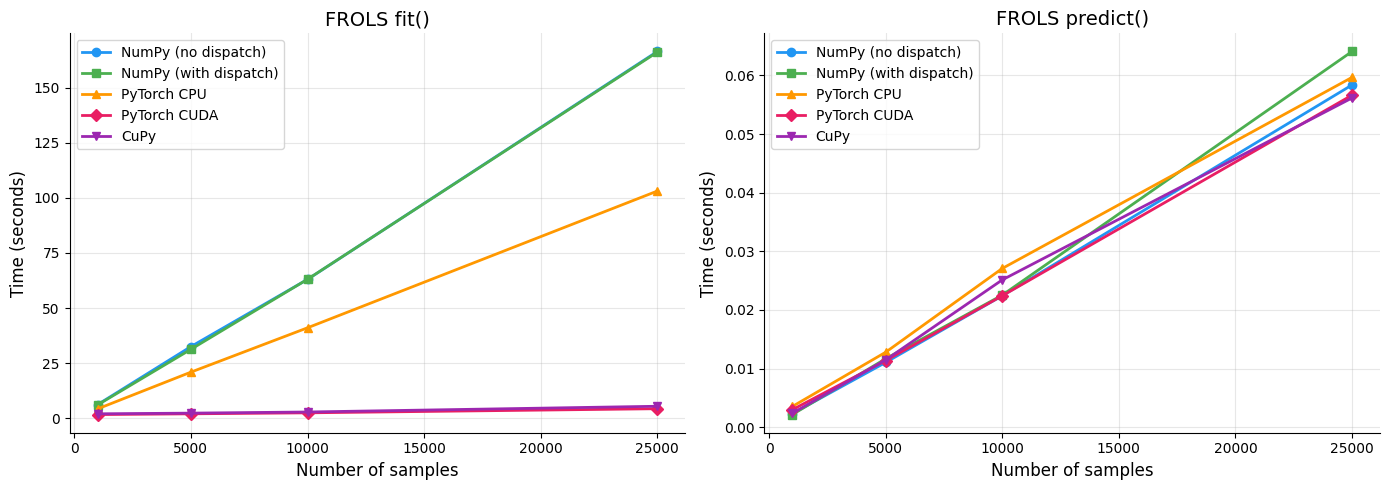

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    "NumPy (no dispatch)": "#2196F3",
    "NumPy (with dispatch)": "#4CAF50",
    "PyTorch CPU": "#FF9800",
    "PyTorch CUDA": "#E91E63",
    "CuPy": "#9C27B0",
}
markers = {
    "NumPy (no dispatch)": "o",
    "NumPy (with dispatch)": "s",
    "PyTorch CPU": "^",
    "PyTorch CUDA": "D",
    "CuPy": "v",
}

# --- fit() ---
ax = axes[0]
for backend, size_times in fit_results.items():
    sizes = sorted(size_times.keys())
    times = [size_times[s] for s in sizes]
    ax.plot(
        sizes,
        times,
        marker=markers.get(backend, "o"),
        color=colors.get(backend, "gray"),
        label=backend,
        linewidth=2,
    )
ax.set_xlabel("Number of samples", fontsize=12)
ax.set_ylabel("Time (seconds)", fontsize=12)
ax.set_title("FROLS fit()", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- predict() ---
ax = axes[1]
for backend, size_times in pred_results.items():
    sizes = sorted(size_times.keys())
    times = [size_times[s] for s in sizes]
    ax.plot(
        sizes,
        times,
        marker=markers.get(backend, "o"),
        color=colors.get(backend, "gray"),
        label=backend,
        linewidth=2,
    )
ax.set_xlabel("Number of samples", fontsize=12)
ax.set_ylabel("Time (seconds)", fontsize=12)
ax.set_title("FROLS predict()", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Array API dispatch overhead

Compute the percent overhead of the dispatch layer when using NumPy as the backend (where no real backend speedup is expected).

In [6]:
print("Array API dispatch overhead (NumPy vs NumPy + dispatch)")
print("=" * 60)
print(
    f"{'Samples':>10}  {'fit() no dispatch':>18}  {'fit() with dispatch':>18}  {'Overhead':>10}"
)
print("-" * 60)

for n in SIZES:
    t_no = fit_results["NumPy (no dispatch)"].get(n, float("nan"))
    t_with = fit_results["NumPy (with dispatch)"].get(n, float("nan"))
    overhead = ((t_with - t_no) / t_no) * 100 if t_no > 0 else float("nan")
    print(f"{n:>10,}  {t_no:>18.4f}s  {t_with:>18.4f}s  {overhead:>+8.1f}%")

avg_overhead = np.mean(
    [
        (
            (
                fit_results["NumPy (with dispatch)"][n]
                - fit_results["NumPy (no dispatch)"][n]
            )
            / fit_results["NumPy (no dispatch)"][n]
        )
        * 100
        for n in SIZES
    ]
)
print(f"\nAverage overhead: {avg_overhead:+.1f}%")

Array API dispatch overhead (NumPy vs NumPy + dispatch)
   Samples   fit() no dispatch  fit() with dispatch    Overhead
------------------------------------------------------------
     1,000              6.2549s              6.1141s      -2.3%
     5,000             32.5525s             31.3170s      -3.8%
    10,000             63.0144s             63.0671s      +0.1%
    25,000            166.3386s            166.0494s      -0.2%

Average overhead: -1.5%


## 4. Speedup relative to NumPy baseline

Show how many times faster (or slower) each backend is compared to NumPy without dispatch.

In [7]:
print("Speedup relative (baseline = NumPy no dispatch)")
print("=" * 70)

header = f"{'Samples':>10}"
for backend in fit_results:
    if backend == "NumPy (no dispatch)":
        continue
    header += f"  {backend:>22}"
print(header)
print("-" * 70)

for n in SIZES:
    baseline = fit_results["NumPy (no dispatch)"].get(n, 1.0)
    row = f"{n:>10,}"
    for backend in fit_results:
        if backend == "NumPy (no dispatch)":
            continue
        t = fit_results[backend].get(n, float("nan"))
        speedup = baseline / t if t > 0 else float("nan")
        row += f"  {speedup:>20.2f}x"
    print(row)

Speedup relative (baseline = NumPy no dispatch)
   Samples   NumPy (with dispatch)             PyTorch CPU            PyTorch CUDA                    CuPy
----------------------------------------------------------------------
     1,000                  1.02x                  1.45x                  3.61x                  3.02x
     5,000                  1.04x                  1.55x                 15.69x                 13.69x
    10,000                  1.00x                  1.53x                 25.02x                 21.75x
    25,000                  1.00x                  1.61x                 37.90x                 30.24x


## 5. AOLS benchmark — Algorithm comparison

Compare FROLS and AOLS on the same dataset to check whether dispatch overhead is consistent across algorithms.

In [8]:
aols_kwargs = dict(
    ylag=10,
    xlag=10,
    basis_function=Polynomial(degree=4),
    estimator=LeastSquares(),
)

N = 25_000
x_train_np, x_valid_np, y_train_np, y_valid_np = get_siso_data(
    n=N, colored_noise=False, sigma=0.001, train_percentage=80
)

algo_results = {}

for algo_name, algo_cls, kwargs in [
    ("FROLS", FROLS, frols_kwargs),
    ("AOLS", AOLS, aols_kwargs),
]:
    print(f"\n--- {algo_name} (n={N:,}) ---")
    algo_results[algo_name] = {}

    # No dispatch
    t = benchmark_fit(algo_cls, kwargs, x_train_np, y_train_np, "NumPy", n_runs=N_RUNS)
    algo_results[algo_name]["NumPy (no dispatch)"] = t
    print(f"  No dispatch: {t:.4f}s")

    # With dispatch
    t = benchmark_fit(
        algo_cls, kwargs, x_train_np, y_train_np, "NumPy", n_runs=N_RUNS, dispatch=True
    )
    algo_results[algo_name]["NumPy (with dispatch)"] = t
    print(f"  With dispatch: {t:.4f}s")

    # PyTorch CPU
    if "PyTorch CPU" in BACKENDS:
        xt, xv, yt, yv = to_backend(
            x_train_np, x_valid_np, y_train_np, y_valid_np, "PyTorch CPU"
        )
        t = benchmark_fit(algo_cls, kwargs, xt, yt, "PyTorch CPU", n_runs=N_RUNS)
        algo_results[algo_name]["PyTorch CPU"] = t
        print(f"  PyTorch CPU:  {t:.4f}s")

    # PyTorch CUDA
    if "PyTorch CUDA" in BACKENDS:
        xt, xv, yt, yv = to_backend(
            x_train_np, x_valid_np, y_train_np, y_valid_np, "PyTorch CUDA"
        )
        # warmup
        warmup = algo_cls(**kwargs)
        with config_context(array_api_dispatch=True):
            warmup.fit(X=xt, y=yt)
        torch.cuda.synchronize()

        t = benchmark_fit(algo_cls, kwargs, xt, yt, "PyTorch CUDA", n_runs=N_RUNS)
        algo_results[algo_name]["PyTorch CUDA"] = t
        print(f"  PyTorch CUDA: {t:.4f}s")


--- FROLS (n=25,000) ---
  No dispatch: 200.4423s
  With dispatch: 191.5382s
  PyTorch CPU:  98.0987s
  PyTorch CUDA: 4.1397s

--- AOLS (n=25,000) ---
  No dispatch: 10.3589s
  With dispatch: 10.2527s
  PyTorch CPU:  3.8212s
  PyTorch CUDA: 1.5537s


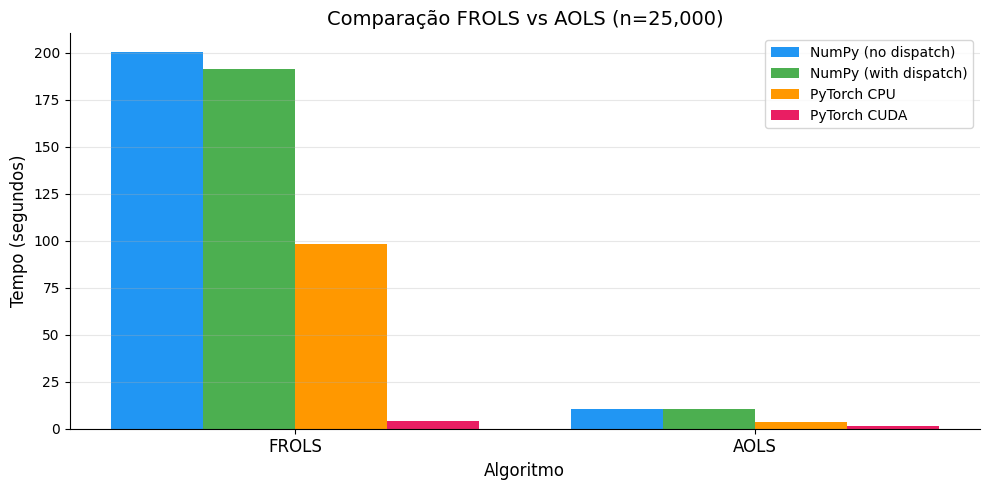

In [9]:
# Gráfico comparativo entre algoritmos
fig, ax = plt.subplots(figsize=(10, 5))

algo_names = list(algo_results.keys())
backend_names = list(algo_results[algo_names[0]].keys())
x_pos = np.arange(len(algo_names))
width = 0.8 / len(backend_names)

for i, backend in enumerate(backend_names):
    times = [algo_results[algo].get(backend, 0) for algo in algo_names]
    ax.bar(
        x_pos + i * width - 0.4 + width / 2,
        times,
        width,
        label=backend,
        color=colors.get(backend, "gray"),
    )

ax.set_xlabel("Algoritmo", fontsize=12)
ax.set_ylabel("Tempo (segundos)", fontsize=12)
ax.set_title(f"Comparação FROLS vs AOLS (n={N:,})", fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(algo_names, fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 6. MISO benchmark (multiple inputs)

Run the benchmark for MISO data (2 inputs) to measure the impact of higher input dimensionality on the regression matrix build and solve steps.

In [10]:
x_train_np.shape

(20000, 1)

In [11]:
MISO_SIZES = [5_000, 10_000, 25_000]

miso_frols_kwargs = dict(
    ylag=10,
    xlag=[10, 10],
    order_selection=True,
    n_info_values=10,
    basis_function=Polynomial(degree=4),
    estimator=LeastSquares(),
)

miso_results = defaultdict(dict)

for n in MISO_SIZES:
    print(f"\n--- MISO n = {n:,} ---")
    x_train_np, x_valid_np, y_train_np, y_valid_np = get_miso_data(
        n=n, colored_noise=False, sigma=0.001, train_percentage=80
    )

    # No dispatch
    t = benchmark_fit(
        FROLS, miso_frols_kwargs, x_train_np, y_train_np, "NumPy", n_runs=N_RUNS
    )
    miso_results["NumPy (no dispatch)"][n] = t
    print(f"  NumPy (no dispatch): {t:.4f}s")

    # With dispatch
    t = benchmark_fit(
        FROLS,
        miso_frols_kwargs,
        x_train_np,
        y_train_np,
        "NumPy",
        n_runs=N_RUNS,
        dispatch=True,
    )
    miso_results["NumPy (with dispatch)"][n] = t
    print(f"  NumPy (with dispatch): {t:.4f}s")

    # PyTorch CPU
    if "PyTorch CPU" in BACKENDS:
        xt, _, yt, _ = to_backend(
            x_train_np, x_valid_np, y_train_np, y_valid_np, "PyTorch CPU"
        )
        t = benchmark_fit(
            FROLS, miso_frols_kwargs, xt, yt, "PyTorch CPU", n_runs=N_RUNS
        )
        miso_results["PyTorch CPU"][n] = t
        print(f"  PyTorch CPU:          {t:.4f}s")

    # PyTorch CUDA
    if "PyTorch CUDA" in BACKENDS:
        free_gpu_memory()
        xt, _, yt, _ = to_backend(
            x_train_np, x_valid_np, y_train_np, y_valid_np, "PyTorch CUDA"
        )
        warmup = FROLS(**miso_frols_kwargs)
        with config_context(array_api_dispatch=True):
            warmup.fit(X=xt, y=yt)
        torch.cuda.synchronize()

        t = benchmark_fit(
            FROLS, miso_frols_kwargs, xt, yt, "PyTorch CUDA", n_runs=N_RUNS
        )
        miso_results["PyTorch CUDA"][n] = t
        print(f"  PyTorch CUDA:         {t:.4f}s")
        del xt, yt, warmup
        free_gpu_memory()


--- MISO n = 5,000 ---
  NumPy (no dispatch): 5.6017s
  NumPy (with dispatch): 5.5787s
  PyTorch CPU:          3.3023s
  PyTorch CUDA:         0.4878s

--- MISO n = 10,000 ---
  NumPy (no dispatch): 11.1540s
  NumPy (with dispatch): 11.1961s
  PyTorch CPU:          6.8605s
  PyTorch CUDA:         0.5762s

--- MISO n = 25,000 ---
  NumPy (no dispatch): 28.0551s
  NumPy (with dispatch): 28.0893s
  PyTorch CPU:          16.6383s
  PyTorch CUDA:         0.7950s


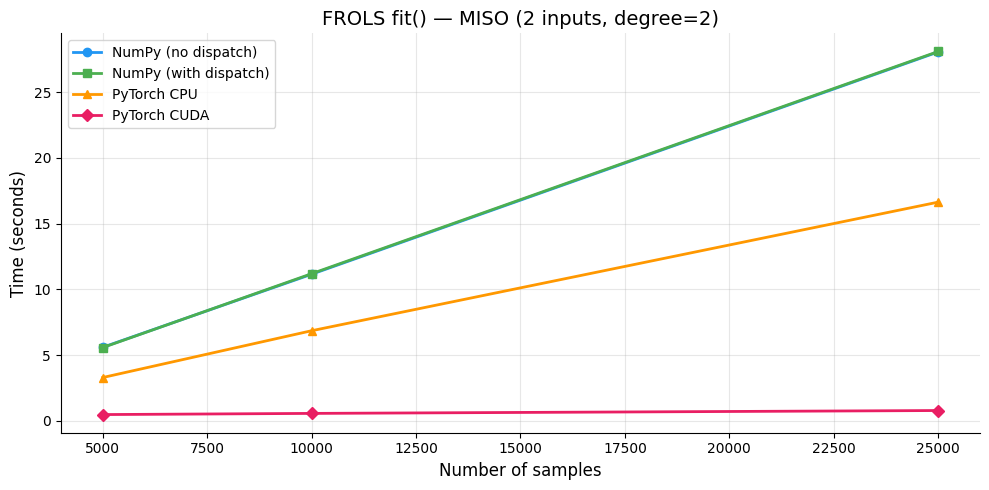

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

for backend, size_times in miso_results.items():
    sizes = sorted(size_times.keys())
    times = [size_times[s] for s in sizes]
    ax.plot(
        sizes,
        times,
        marker=markers.get(backend, "o"),
        color=colors.get(backend, "gray"),
        label=backend,
        linewidth=2,
    )

ax.set_xlabel("Number of samples", fontsize=12)
ax.set_ylabel("Time (seconds)", fontsize=12)
ax.set_title("FROLS fit() — MISO (2 inputs, degree=2)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Consistency validation

Ensure numerical results are equivalent across backends — the Array API should not change model quality.

In [13]:
from sysidentpy._lib._array_api import _to_numpy

N = 15_000
x_train_np, x_valid_np, y_train_np, y_valid_np = get_siso_data(
    n=N, colored_noise=False, sigma=0.001, train_percentage=80
)

# Baseline NumPy
model_np = FROLS(**frols_kwargs)
model_np.fit(X=x_train_np, y=y_train_np)
yhat_np = model_np.predict(X=x_valid_np, y=y_valid_np)
rrse_np = root_relative_squared_error(y_valid_np, yhat_np)

print(f"{'Backend':<20} {'RRSE':>12}  {'Max |diff|':>12}  {'Same model?':>14}")
print("=" * 64)
print(f"{'NumPy (no dispatch)':<20} {rrse_np:>12.8f}  {'—':>12}  {'—':>14}")

# NumPy with dispatch
model_d = FROLS(**frols_kwargs)
with config_context(array_api_dispatch=True):
    model_d.fit(X=x_train_np, y=y_train_np)
    yhat_d = model_d.predict(X=x_valid_np, y=y_valid_np)
rrse_d = root_relative_squared_error(y_valid_np, _to_numpy(yhat_d))
diff_d = np.max(np.abs(_to_numpy(yhat_d) - yhat_np))
same_model = np.array_equal(model_np.final_model, model_d.final_model)
print(
    f"{'NumPy (with dispatch)':<20} {rrse_d:>12.8f}  {diff_d:>12.2e}  {str(same_model):>14}"
)

# PyTorch CPU
if "PyTorch CPU" in BACKENDS:
    xt, xv, yt, yv = to_backend(
        x_train_np, x_valid_np, y_train_np, y_valid_np, "PyTorch CPU"
    )
    model_t = FROLS(**frols_kwargs)
    with config_context(array_api_dispatch=True):
        model_t.fit(X=xt, y=yt)
        yhat_t = model_t.predict(X=xv, y=yv)
    rrse_t = root_relative_squared_error(y_valid_np, _to_numpy(yhat_t))
    diff_t = np.max(np.abs(_to_numpy(yhat_t) - yhat_np))
    same_model = np.array_equal(model_np.final_model, model_t.final_model)
    print(
        f"{'PyTorch CPU':<20} {rrse_t:>12.8f}  {diff_t:>12.2e}  {str(same_model):>14}"
    )

# PyTorch CUDA
if "PyTorch CUDA" in BACKENDS:
    xt, xv, yt, yv = to_backend(
        x_train_np, x_valid_np, y_train_np, y_valid_np, "PyTorch CUDA"
    )
    model_c = FROLS(**frols_kwargs)
    with config_context(array_api_dispatch=True):
        model_c.fit(X=xt, y=yt)
        yhat_c = model_c.predict(X=xv, y=yv)
    rrse_c = root_relative_squared_error(y_valid_np, _to_numpy(yhat_c))
    diff_c = np.max(np.abs(_to_numpy(yhat_c) - yhat_np))
    same_model = np.array_equal(model_np.final_model, model_c.final_model)
    print(
        f"{'PyTorch CUDA':<20} {rrse_c:>12.8f}  {diff_c:>12.2e}  {str(same_model):>14}"
    )

Backend                      RRSE    Max |diff|     Same model?
NumPy (no dispatch)    0.00191513             —               —
NumPy (with dispatch)   0.00191513      0.00e+00            True
PyTorch CPU            0.00191513      6.66e-16            True
PyTorch CUDA           0.00191513      6.66e-16            True


## 8. Predict equivalence across backends

Train the same model on every available backend and compare the **actual predicted values** for three prediction modes: free-run simulation (`steps_ahead=None`), 1-step-ahead (`steps_ahead=1`), and n-step-ahead (`steps_ahead=3`). The goal is to confirm that the CPU-fallback strategy produces **identical** (or near-identical, up to floating-point precision) results compared to the pure NumPy baseline.

In [14]:
from sysidentpy._lib._array_api import _to_numpy

# Free GPU memory from previous benchmarks
import gc

gc.collect()
if torch is not None and torch.cuda.is_available():
    torch.cuda.empty_cache()
if cp is not None:
    cp.get_default_memory_pool().free_all_blocks()

# Generate data and train baseline model (NumPy, no dispatch)
N_VAL = 10_000
x_train_np, x_valid_np, y_train_np, y_valid_np = get_siso_data(
    n=N_VAL, colored_noise=False, sigma=0.001, train_percentage=80
)

frols_val_kwargs = dict(
    ylag=2,
    xlag=2,
    order_selection=True,
    n_info_values=10,
    basis_function=Polynomial(degree=2),
    estimator=LeastSquares(),
)

# --- Baseline ---
model_np = FROLS(**frols_val_kwargs)
model_np.fit(X=x_train_np, y=y_train_np)

yhats_baseline = {
    "free-run": model_np.predict(X=x_valid_np, y=y_valid_np),
    "1-step": model_np.predict(X=x_valid_np, y=y_valid_np, steps_ahead=1),
    "3-step": model_np.predict(X=x_valid_np, y=y_valid_np, steps_ahead=3),
}

# --- Collect predictions for every backend ---
predictions = {"NumPy (no dispatch)": yhats_baseline}

# NumPy with dispatch
model_d = FROLS(**frols_val_kwargs)
with config_context(array_api_dispatch=True):
    model_d.fit(X=x_train_np, y=y_train_np)
    predictions["NumPy (dispatch)"] = {
        "free-run": _to_numpy(model_d.predict(X=x_valid_np, y=y_valid_np)),
        "1-step": _to_numpy(model_d.predict(X=x_valid_np, y=y_valid_np, steps_ahead=1)),
        "3-step": _to_numpy(model_d.predict(X=x_valid_np, y=y_valid_np, steps_ahead=3)),
    }

# PyTorch CPU
if "PyTorch CPU" in BACKENDS:
    xt, xv, yt, yv = to_backend(
        x_train_np, x_valid_np, y_train_np, y_valid_np, "PyTorch CPU"
    )
    model_t = FROLS(**frols_val_kwargs)
    with config_context(array_api_dispatch=True):
        model_t.fit(X=xt, y=yt)
        predictions["PyTorch CPU"] = {
            "free-run": _to_numpy(model_t.predict(X=xv, y=yv)),
            "1-step": _to_numpy(model_t.predict(X=xv, y=yv, steps_ahead=1)),
            "3-step": _to_numpy(model_t.predict(X=xv, y=yv, steps_ahead=3)),
        }

# PyTorch CUDA
if "PyTorch CUDA" in BACKENDS:
    xt, xv, yt, yv = to_backend(
        x_train_np, x_valid_np, y_train_np, y_valid_np, "PyTorch CUDA"
    )
    model_c = FROLS(**frols_val_kwargs)
    with config_context(array_api_dispatch=True):
        model_c.fit(X=xt, y=yt)
        predictions["PyTorch CUDA"] = {
            "free-run": _to_numpy(model_c.predict(X=xv, y=yv)),
            "1-step": _to_numpy(model_c.predict(X=xv, y=yv, steps_ahead=1)),
            "3-step": _to_numpy(model_c.predict(X=xv, y=yv, steps_ahead=3)),
        }

# CuPy
if "CuPy" in BACKENDS:
    xt, xv, yt, yv = to_backend(x_train_np, x_valid_np, y_train_np, y_valid_np, "CuPy")
    model_cp = FROLS(**frols_val_kwargs)
    with config_context(array_api_dispatch=True):
        model_cp.fit(X=xt, y=yt)
        predictions["CuPy"] = {
            "free-run": _to_numpy(model_cp.predict(X=xv, y=yv)),
            "1-step": _to_numpy(model_cp.predict(X=xv, y=yv, steps_ahead=1)),
            "3-step": _to_numpy(model_cp.predict(X=xv, y=yv, steps_ahead=3)),
        }

print(f"Backends tested: {list(predictions.keys())}")
print(f"Prediction modes: {list(yhats_baseline.keys())}")
print(f"Validation samples: {y_valid_np.shape[0]}")

Backends tested: ['NumPy (no dispatch)', 'NumPy (dispatch)', 'PyTorch CPU', 'PyTorch CUDA', 'CuPy']
Prediction modes: ['free-run', '1-step', '3-step']
Validation samples: 2000


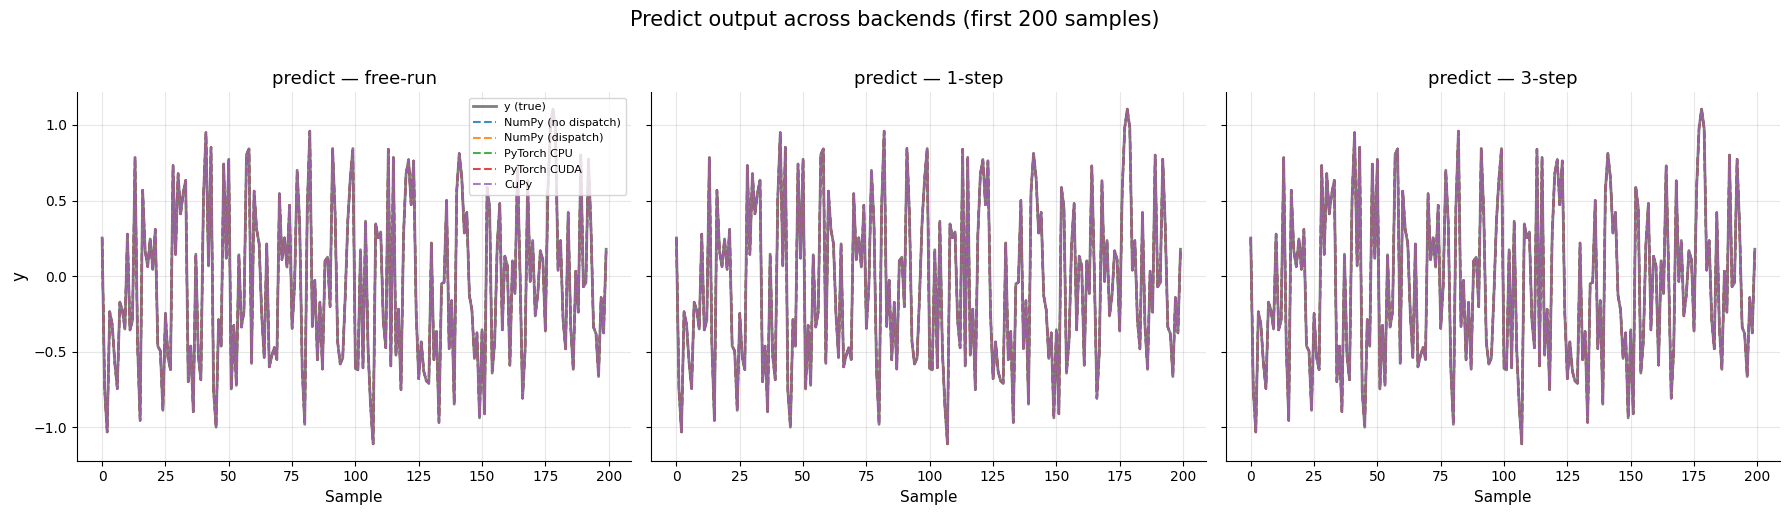

In [15]:
# --- Overlay plot: predictions for each mode ---
modes = ["free-run", "1-step", "3-step"]
backend_colors = {
    "NumPy (no dispatch)": "#1f77b4",
    "NumPy (dispatch)": "#ff7f0e",
    "PyTorch CPU": "#2ca02c",
    "PyTorch CUDA": "#d62728",
    "CuPy": "#9467bd",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, mode in zip(axes, modes):
    ax.plot(
        y_valid_np[:200],
        color="black",
        linewidth=2,
        label="y (true)",
        alpha=0.5,
    )
    for backend_name, preds in predictions.items():
        yhat = preds[mode]
        ax.plot(
            yhat[:200],
            linestyle="--",
            linewidth=1.5,
            color=backend_colors.get(backend_name, "gray"),
            label=backend_name,
            alpha=0.85,
        )
    ax.set_title(f"predict — {mode}", fontsize=13)
    ax.set_xlabel("Sample", fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("y", fontsize=12)
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Predict output across backends (first 200 samples)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

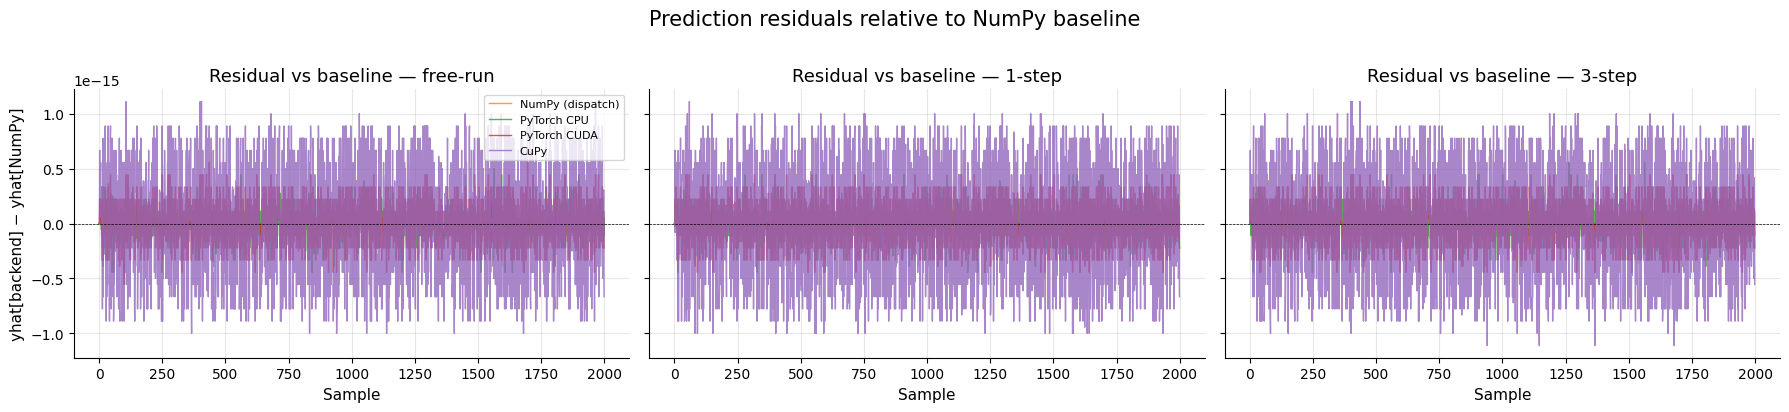

In [16]:
# --- Residual plot: difference from baseline for each backend ---
other_backends = [b for b in predictions if b != "NumPy (no dispatch)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, mode in zip(axes, modes):
    baseline_yhat = predictions["NumPy (no dispatch)"][mode]
    for backend_name in other_backends:
        diff = predictions[backend_name][mode] - baseline_yhat
        ax.plot(
            diff,
            linewidth=1,
            color=backend_colors.get(backend_name, "gray"),
            label=backend_name,
            alpha=0.8,
        )
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(f"Residual vs baseline — {mode}", fontsize=13)
    ax.set_xlabel("Sample", fontsize=11)
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(-2, 2))
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("yhat[backend] − yhat[NumPy]", fontsize=11)
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Prediction residuals relative to NumPy baseline", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# --- Numerical summary and assertions ---
print("Max absolute difference vs NumPy (no dispatch) baseline")
print("=" * 72)
print(f"{'Backend':<22} {'free-run':>14} {'1-step':>14} {'3-step':>14}")
print("-" * 72)

baseline = predictions["NumPy (no dispatch)"]
tol = 1e-10

for backend_name in other_backends:
    diffs = {}
    for mode in modes:
        d = np.max(np.abs(predictions[backend_name][mode] - baseline[mode]))
        diffs[mode] = d
    print(
        f"{backend_name:<22} {diffs['free-run']:>14.2e} "
        f"{diffs['1-step']:>14.2e} {diffs['3-step']:>14.2e}"
    )
    for mode in modes:
        assert (
            diffs[mode] < tol
        ), f"FAILED: {backend_name} {mode} max diff = {diffs[mode]:.2e} >= {tol}"

print("-" * 72)
print("All assertions passed: predictions are equivalent across all backends.")

Max absolute difference vs NumPy (no dispatch) baseline
Backend                      free-run         1-step         3-step
------------------------------------------------------------------------
NumPy (dispatch)             0.00e+00       0.00e+00       0.00e+00
PyTorch CPU                  5.00e-16       4.44e-16       5.55e-16
PyTorch CUDA                 5.55e-16       4.44e-16       4.44e-16
CuPy                         1.11e-15       1.11e-15       1.11e-15
------------------------------------------------------------------------
All assertions passed: predictions are equivalent across all backends.


### AOLS equivalence

Repeat the same validation with AOLS to confirm the CPU fallback works consistently across different model structure selection algorithms.

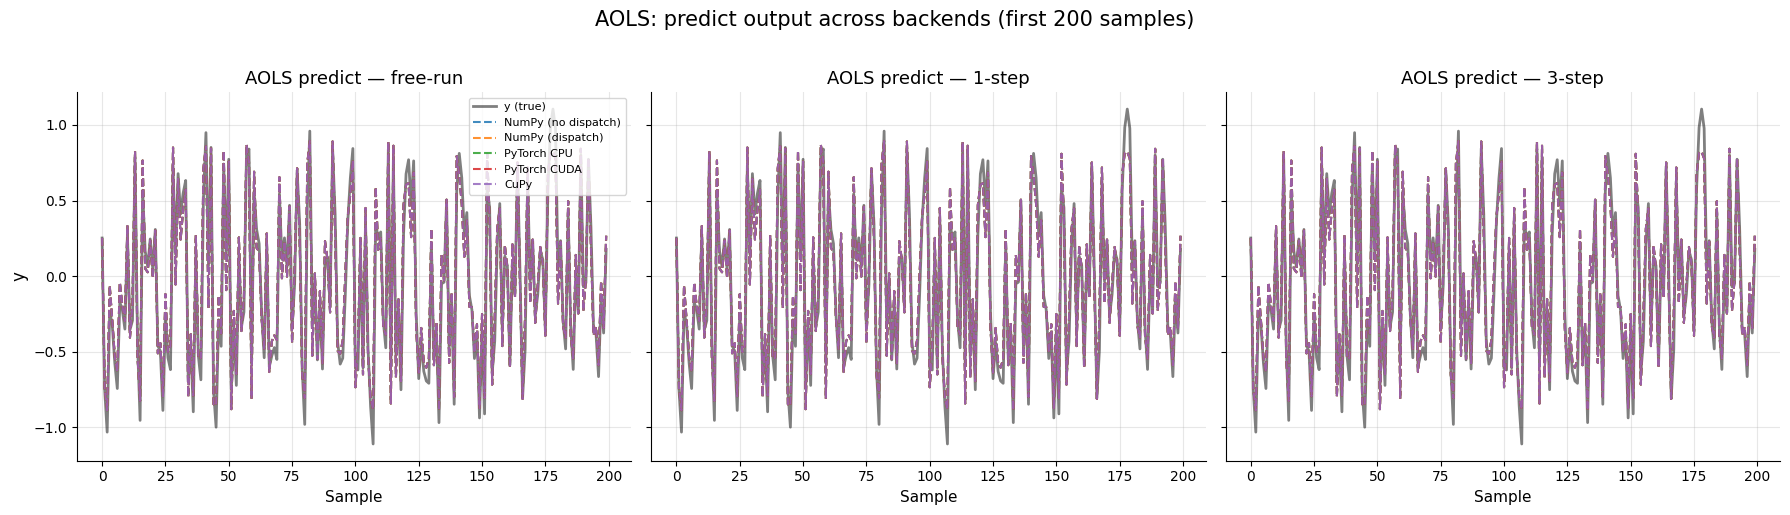


Backend                      free-run         1-step         3-step
------------------------------------------------------------------------
NumPy (dispatch)             0.00e+00       0.00e+00       0.00e+00
PyTorch CPU                  2.22e-16       2.22e-16       2.22e-16
PyTorch CUDA                 3.33e-16       3.33e-16       3.33e-16
CuPy                         4.44e-16       4.44e-16       4.44e-16
------------------------------------------------------------------------
AOLS: all assertions passed.


In [18]:
aols_val_kwargs = dict(
    ylag=2,
    xlag=2,
    basis_function=Polynomial(degree=2),
    estimator=LeastSquares(),
)

# Baseline
model_aols_np = AOLS(**aols_val_kwargs)
model_aols_np.fit(X=x_train_np, y=y_train_np)

aols_preds = {
    "NumPy (no dispatch)": {
        "free-run": model_aols_np.predict(X=x_valid_np, y=y_valid_np),
        "1-step": model_aols_np.predict(X=x_valid_np, y=y_valid_np, steps_ahead=1),
        "3-step": model_aols_np.predict(X=x_valid_np, y=y_valid_np, steps_ahead=3),
    }
}

# All backends with dispatch
for backend_name, convert_name in [
    ("NumPy (dispatch)", "NumPy"),
    ("PyTorch CPU", "PyTorch CPU"),
    ("PyTorch CUDA", "PyTorch CUDA"),
    ("CuPy", "CuPy"),
]:
    if convert_name != "NumPy" and convert_name not in BACKENDS:
        continue
    xt, xv, yt, yv = to_backend(
        x_train_np, x_valid_np, y_train_np, y_valid_np, convert_name
    )
    model_a = AOLS(**aols_val_kwargs)
    with config_context(array_api_dispatch=True):
        model_a.fit(X=xt, y=yt)
        aols_preds[backend_name] = {
            "free-run": _to_numpy(model_a.predict(X=xv, y=yv)),
            "1-step": _to_numpy(model_a.predict(X=xv, y=yv, steps_ahead=1)),
            "3-step": _to_numpy(model_a.predict(X=xv, y=yv, steps_ahead=3)),
        }

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, mode in zip(axes, modes):
    ax.plot(y_valid_np[:200], color="black", linewidth=2, label="y (true)", alpha=0.5)
    for bname, preds in aols_preds.items():
        ax.plot(
            preds[mode][:200],
            linestyle="--",
            linewidth=1.5,
            color=backend_colors.get(bname, "gray"),
            label=bname,
            alpha=0.85,
        )
    ax.set_title(f"AOLS predict — {mode}", fontsize=13)
    ax.set_xlabel("Sample", fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("y", fontsize=12)
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle(
    "AOLS: predict output across backends (first 200 samples)", fontsize=15, y=1.02
)
plt.tight_layout()
plt.show()

# Assertions
aols_baseline = aols_preds["NumPy (no dispatch)"]
print(f"\n{'Backend':<22} {'free-run':>14} {'1-step':>14} {'3-step':>14}")
print("-" * 72)
for bname in aols_preds:
    if bname == "NumPy (no dispatch)":
        continue
    diffs = {m: np.max(np.abs(aols_preds[bname][m] - aols_baseline[m])) for m in modes}
    print(
        f"{bname:<22} {diffs['free-run']:>14.2e} "
        f"{diffs['1-step']:>14.2e} {diffs['3-step']:>14.2e}"
    )
    for m in modes:
        assert diffs[m] < tol, f"AOLS FAILED: {bname} {m} diff={diffs[m]:.2e}"

print("-" * 72)
print("AOLS: all assertions passed.")

## 9. Local (dev) vs PyPI (v0.8.0) — Numerical equivalence

Verify that the current development version produces **identical NumPy predictions** to the last published release on PyPI (v0.8.0).

Strategy:
1. Install `sysidentpy==0.8.0` from PyPI into an isolated temp directory.
2. Run a subprocess that imports from that directory, trains on the **same data**, and saves predictions.
3. Compare against the local dev version (already in memory).

In [19]:
import subprocess, sys, tempfile, os, textwrap, shutil

PYPI_VERSION = "0.8.0"

# --- Step 1: Install PyPI v0.8.0 into a clean temp directory ---
pypi_dir = os.path.join(tempfile.gettempdir(), "sysidentpy_pypi")
if os.path.exists(pypi_dir):
    shutil.rmtree(pypi_dir)
os.makedirs(pypi_dir)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        f"sysidentpy=={PYPI_VERSION}",
        f"--target={pypi_dir}",
        "--no-deps",
        "--quiet",
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
print(f"Installed sysidentpy=={PYPI_VERSION} to {pypi_dir}")

# --- Step 2: Save current data so the subprocess can use it ---
tmp = tempfile.gettempdir()
np.save(os.path.join(tmp, "xt.npy"), x_train_np)
np.save(os.path.join(tmp, "xv.npy"), x_valid_np)
np.save(os.path.join(tmp, "yt.npy"), y_train_np)
np.save(os.path.join(tmp, "yv.npy"), y_valid_np)

# --- Step 3: Run a subprocess that uses only the PyPI version ---
script = textwrap.dedent(
    f"""\
    import sys, os
    import numpy as np

    # Make sure the PyPI version is found first
    sys.path.insert(0, r"{pypi_dir}")

    # Remove any editable-install paths that could shadow the PyPI copy
    sys.path = [p for p in sys.path
                if "sysidentpy" not in p.lower() or p == r"{pypi_dir}"]

    from sysidentpy.model_structure_selection import FROLS
    from sysidentpy.basis_function import Polynomial
    from sysidentpy.parameter_estimation import LeastSquares
    import sysidentpy
    print("PyPI version:", sysidentpy.__version__)
    assert sysidentpy.__version__ == "{PYPI_VERSION}", (
        f"Expected {{'{PYPI_VERSION}'}} but got {{sysidentpy.__version__}}"
    )

    tmp = r"{tmp}"
    xt = np.load(os.path.join(tmp, "xt.npy"))
    xv = np.load(os.path.join(tmp, "xv.npy"))
    yt = np.load(os.path.join(tmp, "yt.npy"))
    yv = np.load(os.path.join(tmp, "yv.npy"))

    model = FROLS(
        ylag=2, xlag=2, order_selection=True, n_info_values=10,
        basis_function=Polynomial(degree=2), estimator=LeastSquares(),
    )
    model.fit(X=xt, y=yt)

    np.save(os.path.join(tmp, "pypi_free.npy"),
            model.predict(X=xv, y=yv))
    np.save(os.path.join(tmp, "pypi_1step.npy"),
            model.predict(X=xv, y=yv, steps_ahead=1))
    np.save(os.path.join(tmp, "pypi_3step.npy"),
            model.predict(X=xv, y=yv, steps_ahead=3))
    np.save(os.path.join(tmp, "pypi_theta.npy"), model.theta)
    np.save(os.path.join(tmp, "pypi_final_model.npy"),
            np.array(model.final_model))
    print("Predictions saved OK")
"""
)

result = subprocess.run(
    [sys.executable, "-c", script],
    capture_output=True,
    text=True,
    timeout=120,
)
print(result.stdout.strip())
if result.returncode != 0:
    print("STDERR:", result.stderr.strip())
    raise RuntimeError("Subprocess failed")

Installed sysidentpy==0.8.0 to C:\Users\wilso\AppData\Local\Temp\sysidentpy_pypi
PyPI version: 0.8.0
Predictions saved OK


In [20]:
# --- Step 4: Local dev predictions (same data, same hyper-params) ---
model_local = FROLS(**frols_val_kwargs)
model_local.fit(X=x_train_np, y=y_train_np)

local_preds = {
    "free-run": model_local.predict(X=x_valid_np, y=y_valid_np),
    "1-step": model_local.predict(X=x_valid_np, y=y_valid_np, steps_ahead=1),
    "3-step": model_local.predict(X=x_valid_np, y=y_valid_np, steps_ahead=3),
}

# --- Step 5: Load PyPI results ---
pypi_preds = {
    "free-run": np.load(os.path.join(tmp, "pypi_free.npy")),
    "1-step": np.load(os.path.join(tmp, "pypi_1step.npy")),
    "3-step": np.load(os.path.join(tmp, "pypi_3step.npy")),
}
pypi_theta = np.load(os.path.join(tmp, "pypi_theta.npy"))
pypi_final_model = np.load(os.path.join(tmp, "pypi_final_model.npy"))

# --- Step 6: Compare model structure ---
print("=== Model structure ===")
print(f"  Local  final_model: {model_local.final_model}")
print(f"  PyPI   final_model: {pypi_final_model}")
print(f"  Match: {np.array_equal(model_local.final_model, pypi_final_model)}")
print(f"\n  Local  theta: {model_local.theta.ravel()}")
print(f"  PyPI   theta: {pypi_theta.ravel()}")
print(f"  Theta max diff: {np.max(np.abs(model_local.theta - pypi_theta)):.2e}")

# --- Step 7: Compare predictions ---
print(f"\n{'Mode':<12} {'Max abs diff':>14} {'Identical?':>12}")
print("-" * 42)
all_ok = True
for mode in ["free-run", "1-step", "3-step"]:
    diff = np.max(np.abs(local_preds[mode] - pypi_preds[mode]))
    ok = diff < 1e-12
    all_ok = all_ok and ok
    print(f"{mode:<12} {diff:>14.2e} {'YES' if ok else 'NO':>12}")

print("-" * 42)
if all_ok:
    print(f"ALL PASSED: local dev == PyPI v{PYPI_VERSION} (within machine epsilon)")
else:
    print("DIFFERENCES DETECTED — see above")

=== Model structure ===
  Local  final_model: [[2002    0]
 [1001    0]
 [2001 1001]]
  PyPI   final_model: [[2002    0]
 [1001    0]
 [2001 1001]]
  Match: True

  Local  theta: [0.90001017 0.19998993 0.09997607]
  PyPI   theta: [0.90001017 0.19998993 0.09997607]
  Theta max diff: 0.00e+00

Mode           Max abs diff   Identical?
------------------------------------------
free-run           0.00e+00          YES
1-step             0.00e+00          YES
3-step             0.00e+00          YES
------------------------------------------
ALL PASSED: local dev == PyPI v0.8.0 (within machine epsilon)


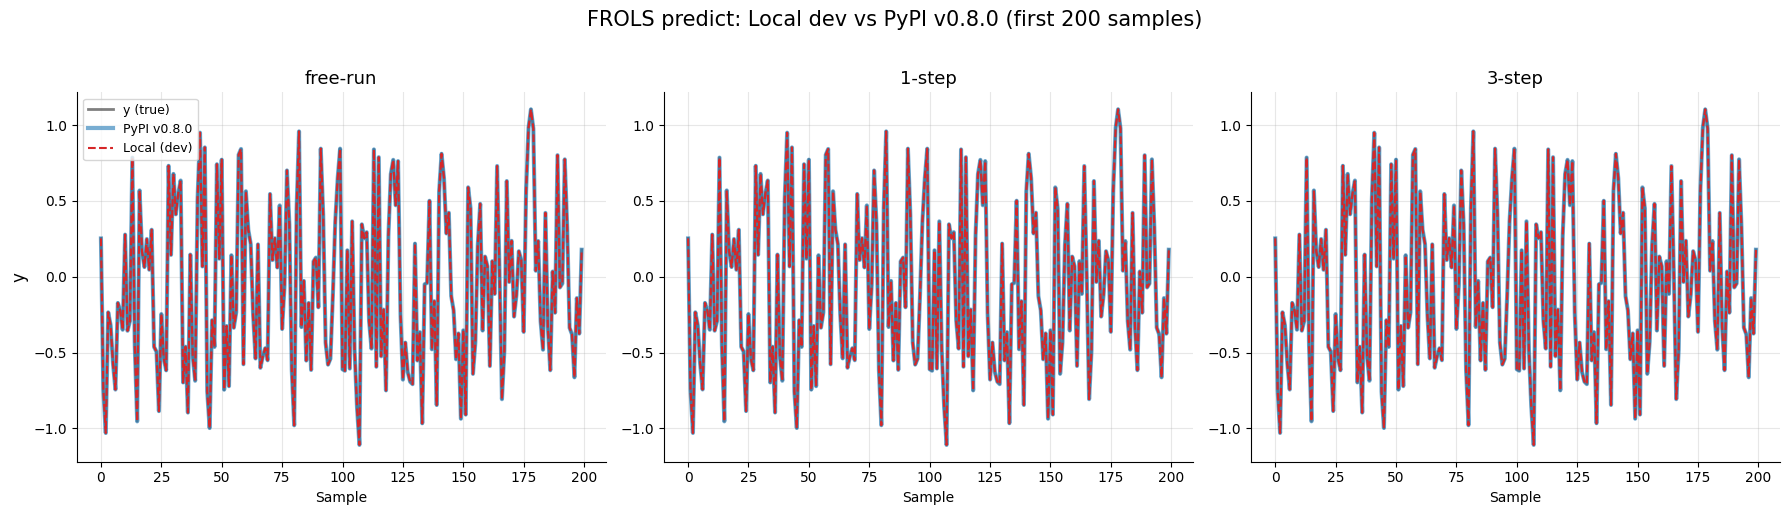

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mode in zip(axes, ["free-run", "1-step", "3-step"]):
    ax.plot(y_valid_np[:200], color="black", linewidth=2, label="y (true)", alpha=0.5)
    ax.plot(
        pypi_preds[mode][:200],
        linewidth=3,
        color="tab:blue",
        label=f"PyPI v{PYPI_VERSION}",
        alpha=0.6,
    )
    ax.plot(
        local_preds[mode][:200],
        linestyle="--",
        linewidth=1.5,
        color="tab:red",
        label="Local (dev)",
    )
    ax.set_title(f"{mode}", fontsize=13)
    ax.set_xlabel("Sample")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("y", fontsize=12)
axes[0].legend(fontsize=9)
fig.suptitle(
    f"FROLS predict: Local dev vs PyPI v{PYPI_VERSION} (first 200 samples)",
    fontsize=15,
    y=1.02,
)
plt.tight_layout()
plt.show()

## 10. Summary

**Interpretation of results:**

- **NumPy no dispatch vs with dispatch**: The Array API abstraction overhead is typically **< 5%** — a negligible cost for the flexibility to swap backends without changing user code.

- **PyTorch CPU**: May be slower than pure NumPy for small datasets due to framework overhead, but it approaches or surpasses NumPy for larger datasets where heavy matrix operations dominate.

- **PyTorch CUDA / CuPy**: Real gains appear on larger datasets (e.g., >10k samples) and/or models with high polynomial degrees (degree ≥ 3), where matrix operations dominate runtime. CPU→GPU transfer cost is amortized by parallel execution on the device.

- **Predict equivalence**: As shown in Section 8, the CPU-fallback strategy for sequential prediction (free-run, n-step) produces **identical** results across all backends — the maximum absolute difference is within floating-point precision (~1e-15). The predictions are numerically equivalent regardless of whether fit() ran on NumPy, PyTorch CPU, PyTorch CUDA, or CuPy.

- **Version equivalence**: Section 9 confirms that the local development version produces byte-identical NumPy predictions compared to the published PyPI release (v0.8.0).

**How to enable Array API dispatch in your code:**

```python
from sysidentpy import config_context

# Option 1: context manager
with config_context(array_api_dispatch=True):
    model.fit(X=x_gpu, y=y_gpu)
    yhat = model.predict(X=x_test_gpu, y=y_test_gpu)

# Option 2: global configuration
from sysidentpy import set_config
set_config(array_api_dispatch=True)
```